<a href="https://colab.research.google.com/github/beaudougan1/FraudDetection/blob/main/FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Dataset loading taken from kaggle
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = ""

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nelgiriyewithana/credit-card-fraud-detection-dataset-2023",
  path = "creditcard_2023.csv",
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/tmp/ipykernel_7049/854204752.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'credit-card-fraud-detection-dataset-2023' dataset.


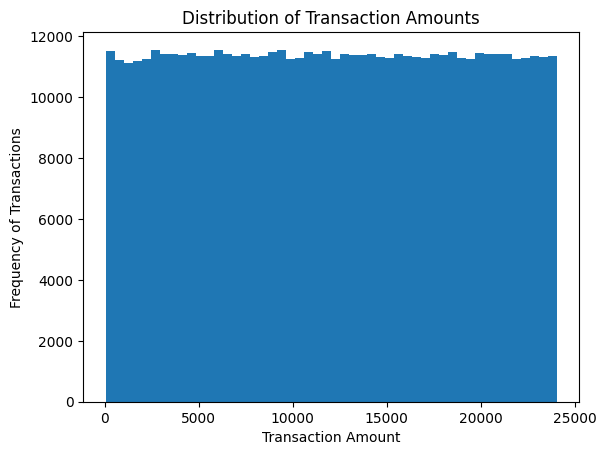

In [ ]:
#Visualize transaction amounts
plt.hist(df['Amount'], bins=50)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency of Transactions")
plt.show()

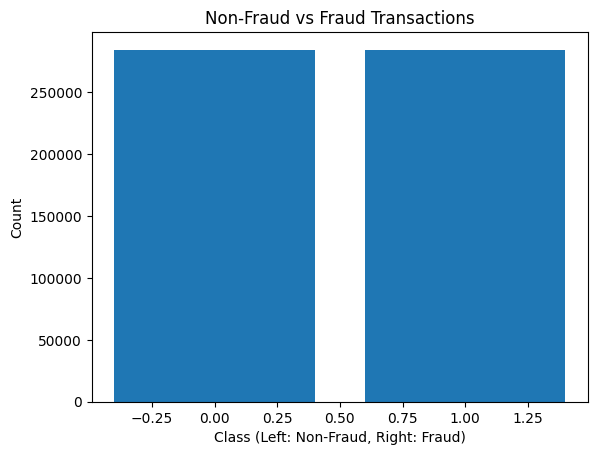

In [ ]:
#Visualize class distribution
counts = df['Class'].value_counts()
plt.title("Non-Fraud vs Fraud Transactions")
plt.bar(counts.index, counts.values)
plt.xlabel("Class (Left: Non-Fraud, Right: Fraud)")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_7049/4248838158.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([nonfraud, fraud], labels = ['Non-Fraud', 'Fraud'])


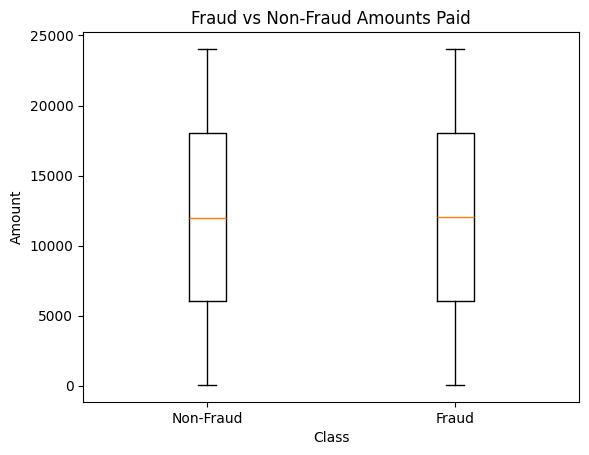

In [ ]:
#Visualize fraud vs non fraud amounts paid
fraud = df[df['Class'] == 1]['Amount']
nonfraud = df[df['Class'] == 0]['Amount']

plt.boxplot([nonfraud, fraud], labels = ['Non-Fraud', 'Fraud'])
plt.title("Fraud vs Non-Fraud Amounts Paid")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.show()

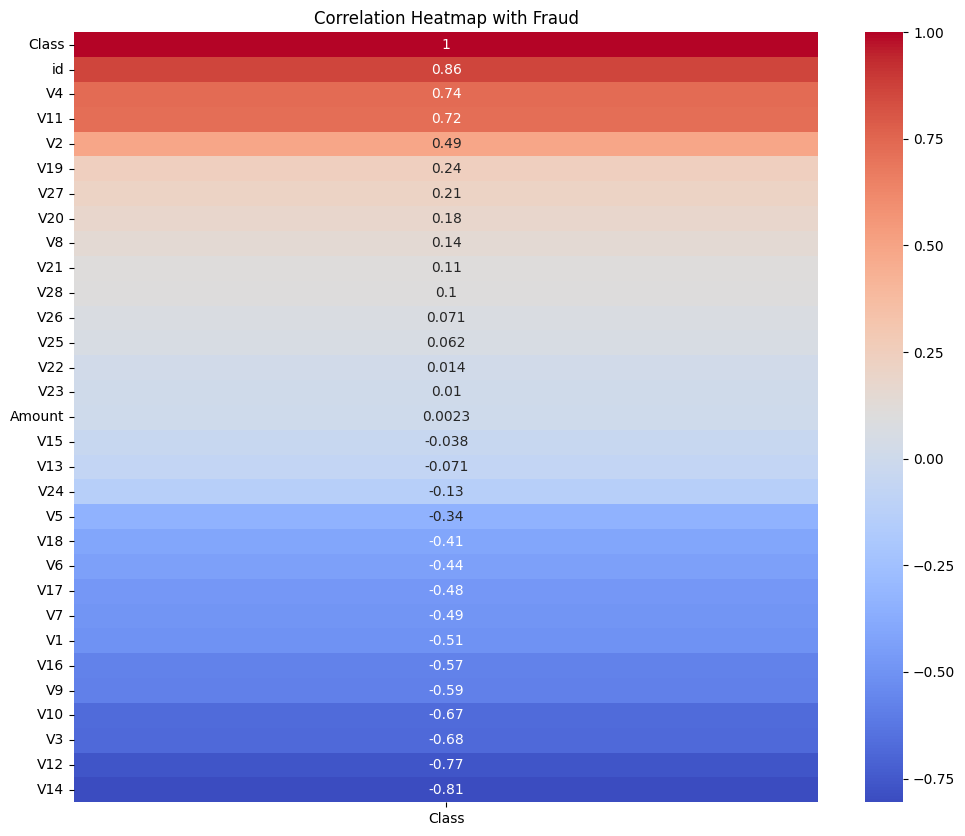

In [ ]:
#Create a heatmap to find correlation between features and fraud
corr = df.corr()

plt.figure(figsize=(12, 10))
plt.title("Correlation Heatmap with Fraud")
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False), annot=True, cmap='coolwarm')
plt.show()

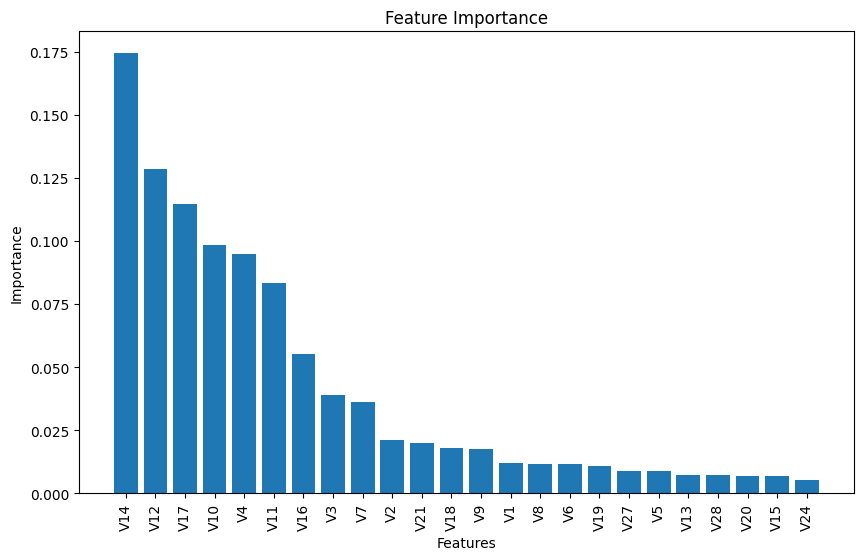

In [ ]:
#Drop id before starting since it shows up as highly correlated and is irrelevent
df = df.drop(columns=['id'])

#Drop features that are not correlated much with fraud (less than .01)
df = df.drop(columns=['Amount', 'V22', 'V23', 'V25', 'V26'])

#Check important features using random forest

from sklearn.ensemble import RandomForestClassifier

dfSample = df.sample(n=50000, random_state=42)

x= dfSample.drop(columns=['Class'])
y= dfSample['Class']

model = RandomForestClassifier()
model.fit(x, y)

importances = model.feature_importances_

features = x.columns
#sort importances in reverse order
sortedIdx = np.argsort(importances)[::-1]
#Visualize important features
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[sortedIdx])
plt.xticks(range(len(importances)), features[sortedIdx], rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()


In [ ]:
#Create a new features list with only the most correlated features
bestFeatures = ['V14', 'V4', 'V10', 'V17', 'V12', 'V11', 'V3', 'V16']
x = df[bestFeatures]
y = df['Class']

#Create a train test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)
#Further split for validation set
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    random_state=42
)

#Train logistic regression models
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression(C = 1, solver = 'lbfgs')
model1.fit(x_train, y_train)
model2 = LogisticRegression(C = .01, solver = 'saga')
model2.fit(x_train, y_train)

#Test models on validation set
from sklearn.metrics import recall_score
prediction = model1.predict(x_val)
prediction2 = model2.predict(x_val)
recall1 = recall_score(y_val, prediction)
recall2 = recall_score(y_val, prediction2)
print("Logistic Regression for Validation Set\n")
print("Recall for Model 1: ", recall1)
print("Recall for Model 2: ", recall2)

Logistic Regression for Validation Set

Recall for Model 1:  0.9368985609605368
Recall for Model 2:  0.9331243930431712


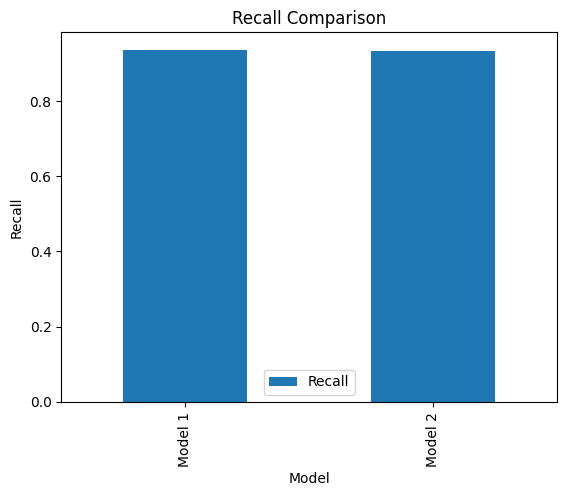

In [ ]:
import pandas as pd
#Compare models
df = pd.DataFrame([recall1, recall2], columns=['Recall'], index=['Model 1', 'Model 2'])
df.plot(kind='bar')
plt.title("Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.show()

In [ ]:
#Check results for both models on training set
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
LRprediction = model1.predict(x_test)
LRprediction2 = model2.predict(x_test)
#Make confusion matrixs for each
cm = confusion_matrix(y_test, LRprediction)
cm2 = confusion_matrix(y_test, LRprediction2)
#Print results
print("Logistic Regression Model 1 \n")
print(cm)
print(classification_report(y_test, LRprediction))
print("\n")

print("Logistic Regression Model 2 \n")
print(cm2)
print(classification_report(y_test, LRprediction2))

Logistic Regression Model 1 

[[55527  1223]
 [ 3487 53489]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     56750
           1       0.98      0.94      0.96     56976

    accuracy                           0.96    113726
   macro avg       0.96      0.96      0.96    113726
weighted avg       0.96      0.96      0.96    113726



Logistic Regression Model 2 

[[55633  1117]
 [ 3691 53285]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     56750
           1       0.98      0.94      0.96     56976

    accuracy                           0.96    113726
   macro avg       0.96      0.96      0.96    113726
weighted avg       0.96      0.96      0.96    113726



In [ ]:
#Train random forest models
from sklearn.ensemble import RandomForestClassifier

model1 = RandomForestClassifier(n_estimators = 100, max_depth = 10)
model2 = RandomForestClassifier(n_estimators = 50, max_depth = 5)
model1.fit(x_train, y_train)
model2.fit(x_train, y_train)

#Check results for the validation set
prediction = model1.predict(x_val)
prediction2 = model2.predict(x_val)
recall1 = recall_score(y_val, prediction)
recall2 = recall_score(y_val, prediction2)
print("Random Forest for Validation Set\n")
print("Recall for Model 1: ", recall1)
print("Recall for Model 2: ", recall2)

Random Forest for Validation Set

Recall for Model 1:  0.962964597863512
Recall for Model 2:  0.9161075306789088


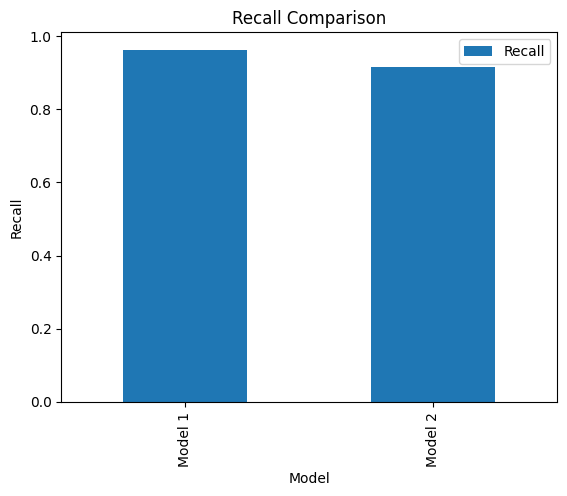

In [ ]:
#Compare models
df = pd.DataFrame([recall1, recall2], columns=['Recall'], index=['Model 1', 'Model 2'])
df.plot(kind='bar')
plt.title("Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.show()

In [ ]:
#Check results on test set
RFprediction = model1.predict(x_test)
RFprediction2 = model2.predict(x_test)
cm = confusion_matrix(y_test, RFprediction)
cm2 = confusion_matrix(y_test, RFprediction2)
#print results for both models
print("Random Forest Model \n")
print(cm)
print("\n")
print(classification_report(y_test, RFprediction))
print("\n")

print("Random Forest Model 2 \n")
print(cm2)
print("\n")
print(classification_report(y_test, RFprediction2))

Random Forest Model 

[[56438   312]
 [ 2070 54906]]


              precision    recall  f1-score   support

           0       0.96      0.99      0.98     56750
           1       0.99      0.96      0.98     56976

    accuracy                           0.98    113726
   macro avg       0.98      0.98      0.98    113726
weighted avg       0.98      0.98      0.98    113726



Random Forest Model 2 

[[56357   393]
 [ 4635 52341]]


              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56750
           1       0.99      0.92      0.95     56976

    accuracy                           0.96    113726
   macro avg       0.96      0.96      0.96    113726
weighted avg       0.96      0.96      0.96    113726



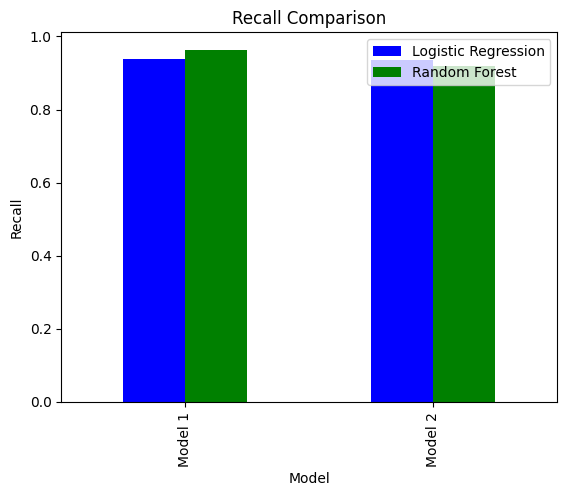

In [ ]:
#Compare models
LRRecalls = [
    recall_score(y_test, LRprediction),
    recall_score(y_test, LRprediction2)
]
RFRecalls = [
    recall_score(y_test, RFprediction),
    recall_score(y_test, RFprediction2)
]

#Graph model comparison
df = pd.DataFrame([LRRecalls, RFRecalls], columns=['Model 1', 'Model 2'], index=['Logistic Regression', 'Random Forest'])
df.T.plot(kind='bar', color=['blue','green'])
plt.title("Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.show()